# Task 1 — Inductive Biases and Feature Representations

This notebook probes how three frozen visual backbones — **ResNet-50**
(CNN), **ViT-B/16** (vision transformer), and **CLIP ViT-B/32** (contrastive
image-text) — differ in their inductive biases toward **color**, **shape vs.
texture**, **translation**, and **local patch structure**, and how those
differences show up both in downstream predictions and in the geometry of
their frozen feature spaces.

**Pipeline:** train a linear probe per backbone on frozen STL-10 features →
evaluate all backbones (+ CLIP zero-shot) on a fixed 500-image balanced test
subset → apply four families of pixel-space interventions to that *same*
subset → measure accuracy / consistency / representation stability under
each intervention.

All stochastic choices (splits, subset selection, color-swap pairing, patch
permutations, projection fits) are seeded from a single master seed
(`SEED = 6304`) via `utils.config.make_rng`, so every artifact here is
reproducible from a clean run of this notebook.


## 1. Setup & Configuration

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image

from utils.config import (
    SEED, DEVICE, USE_CUDA, IMG_SIZE, STL10_CLASSES,
    RESULTS_DIR, CACHE_DIR, FIGURES_DIR,
    seed_everything, make_rng, autocast_ctx, save_json, load_json,
)
from utils import backbones as bb
from utils import transforms as tr
from utils import data as dm
from utils import metrics as mx
from utils.adain import AdaINStyleTransfer
from analysis import cue_conflict_calibration as cuecal

seed_everything(SEED)
print(f"Device: {DEVICE} | CUDA: {USE_CUDA} | classes: {STL10_CLASSES}")


Device: cuda | CUDA: True | classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


**Execution environment.** The populated run used a CUDA-capable environment
with the pretrained ImageNet/OpenAI-CLIP backbones, STL-10, and local AdaIN
encoder/decoder checkpoints. Restart the kernel and run top-to-bottom after
changing calibration settings so cached and downstream artifacts remain aligned.


## 2. Backbone Wrapper Classes

Each backbone is wrapped so that the shared pipeline can call
`.forward_features(images_0_1)` uniformly, with backbone-specific
normalization applied *inside* the wrapper (never baked into cached
images — see `utils/backbones.py`). All backbones are frozen and kept in
`eval()` mode permanently.

| Backbone | Weights | Representation |
|---|---|---|
| ResNet-50 | `IMAGENET1K_V2` | 2048-d global-average-pooled feature |
| ViT-B/16 | `IMAGENET1K_V1` | `[CLS]` token embedding (768-d) |
| CLIP ViT-B/32 | OpenAI `openai` weights | L2-normalized image embedding (512-d) |


In [2]:
backbone_dict = bb.build_backbones(device=DEVICE)
resnet, vit, clip = backbone_dict["resnet50"], backbone_dict["vit_b_16"], backbone_dict["clip_vit_b_32"]
for name, model in backbone_dict.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {n_params/1e6:.1f}M params, feature_dim={model.feature_dim}, frozen={not any(p.requires_grad for p in model.parameters())}")


resnet50: 23.5M params, feature_dim=2048, frozen=True
vit_b_16: 86.6M params, feature_dim=768, frozen=True
clip_vit_b_32: 151.3M params, feature_dim=512, frozen=True


In [3]:
# Sanity check: CLIP zero-shot prompts
print([f"a photo of a {c}." for c in STL10_CLASSES])


['a photo of a airplane.', 'a photo of a bird.', 'a photo of a car.', 'a photo of a cat.', 'a photo of a deer.', 'a photo of a dog.', 'a photo of a horse.', 'a photo of a monkey.', 'a photo of a ship.', 'a photo of a truck.']


## 3. Dataset Loading, Stratified Split, Linear-Head Training

- Dataset: **STL-10** (`torchvision.datasets.STL10`), 10 classes.
- Images are resized to 224×224 and kept as `[0,1]` float RGB tensors — no
  backbone normalization at this stage (Sec. 4 of the spec: normalization is
  applied last, per-backbone).
- Stratified 80/20 split of the **official train partition**, seed 6304.
- One linear head (`in_features -> 10`) per backbone, trained on **cached**
  frozen features (extracted once, reused across all 50 epochs).
- AdamW, lr=1e-3, weight_decay=1e-4, max 50 epochs, early stopping after 5
  epochs without validation-accuracy improvement.


In [4]:
train_ds, test_ds = dm.get_datasets(download=True)
print(f"STL-10 train: {len(train_ds)}, test: {len(test_ds)}")

train_subset, val_subset = dm.stratified_split(train_ds, train_frac=0.8, seed_name="stratified_split")
print(f"Stratified split -> train: {len(train_subset)}, val: {len(val_subset)}")

train_loader_raw = dm.make_loader(train_subset, batch_size=128, shuffle=False)
val_loader_raw = dm.make_loader(val_subset, batch_size=128, shuffle=False)


STL-10 train: 5000, test: 8000
Stratified split -> train: 4000, val: 1000


In [5]:
# Extract & cache frozen features for train/val once per backbone (clean condition).
linear_heads = {}
head_histories = {}

for name, model in backbone_dict.items():
    t0 = time.time()
    train_feat = dm.extract_features(model, train_loader_raw, condition="clean_train")
    val_feat = dm.extract_features(model, val_loader_raw, condition="clean_val")
    print(f"[{name}] feature extraction: {time.time()-t0:.1f}s "
          f"(train={train_feat['features'].shape}, val={val_feat['features'].shape})")

    head, history = dm.train_linear_head(
        train_feats=train_feat["features"], train_labels=train_feat["labels"],
        val_feats=val_feat["features"], val_labels=val_feat["labels"],
        in_features=model.feature_dim, num_classes=len(STL10_CLASSES),
        seed=SEED,
    )
    linear_heads[name] = head
    head_histories[name] = history
    print(f"[{name}] best val acc = {history['best_val_acc']:.4f} "
          f"(stopped after {history['epochs_run']} epochs)")

save_json({k: {kk: vv for kk, vv in v.items() if kk != 'train_loss'} for k, v in head_histories.items()},
          RESULTS_DIR / "linear_head_training_summary.json")


[resnet50] feature extraction: 32.7s (train=torch.Size([4000, 2048]), val=torch.Size([1000, 2048]))


/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task1/utils/data.py:279: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)


Training linear head:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 2/50:   0%|          | 0/16 [00:00<?, ?batch/s]

...

Epoch 12/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 13/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 14/50:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 15/50:   0%|          | 0/16 [00:00<?, ?batch/s]

[clip_vit_b_32] best val acc = 0.9850 (stopped after 15 epochs)


## 4. Class-Balanced Evaluation Subset (500 images)

Selected once from the **official STL-10 test partition**, seed 6304, and
reused **unchanged** for every model and every intervention in the rest of
this notebook. If a class has fewer than 50 available images the shortfall
is logged explicitly (STL-10's test split has 800 images/class, so no
shortfall is expected here, but the logic below handles it generically).


In [6]:
eval_subset = dm.select_eval_subset(test_ds, total=500, seed_name="eval_subset")
save_json(eval_subset, RESULTS_DIR / "eval_subset_ids.json")

print(f"Selected {eval_subset['total_selected']} images "
      f"(target {eval_subset['total_requested']}, {eval_subset['per_class_target']}/class)")
if eval_subset["shortfall_log"]:
    print("Shortfalls:", eval_subset["shortfall_log"])
else:
    print("No shortfalls — every class reached its target count.")

eval_image_ids = eval_subset["image_ids"]
eval_labels = eval_subset["labels"]
eval_indices = eval_subset["indices"]


Selected 500 images (target 500, 50/class)
No shortfalls — every class reached its target count.


In [7]:
from torch.utils.data import Subset

eval_ds_clean = Subset(test_ds, eval_indices)
eval_loader_clean = dm.make_loader(eval_ds_clean, batch_size=100, shuffle=False)


## 5. Shared Transform Pipeline

Implemented once in `utils/transforms.py` and reused for every backbone:
`to_grayscale3`, `class_swap_color_transfer` (+ its LAB stats/derangement
helpers), `translate_reflect`, and `patch_shuffle`. Each operates on
`[0,1]` RGB tensors at 224×224 — the exact same pixels are then fed through
every backbone's own `.normalize()`, guaranteeing pixel-identical inputs
across models for a given condition (Sec. 4 of the spec).

A helper below runs any backbone + linear head over a full `DataLoader`
that yields already-intervened images, producing predictions/logits/labels/
ids in one pass (used repeatedly in Steps 1–5).


In [8]:
@torch.no_grad()
def run_head_over_loader(model, head, loader, condition, cache=True):
    feat_bundle = dm.extract_features(model, loader, condition=condition, cache=cache)
    feats = feat_bundle["features"].to(DEVICE)
    labels = feat_bundle["labels"]
    ids = feat_bundle["image_ids"]
    head.eval()
    with autocast_ctx():
        logits = head(feats)
    preds = logits.argmax(dim=-1).cpu().numpy().tolist()
    return {
        "preds": preds, "labels": labels, "image_ids": ids,
        "logits": logits.float().cpu(), "features": feat_bundle["features"],
    }


@torch.no_grad()
def run_clip_zero_shot_over_loader(clip_model, loader, condition):
    all_preds, all_labels, all_ids, all_conf = [], [], [], []
    for imgs, lbls, ids in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        pred, conf = clip_model.zero_shot_predict(imgs)
        all_preds.extend(pred.cpu().tolist())
        all_conf.extend(conf.cpu().tolist())
        all_labels.extend([int(x) for x in lbls])
        all_ids.extend(list(ids))
    return {"preds": all_preds, "labels": all_labels, "image_ids": all_ids, "confidences": all_conf}


## 6. Step 1 — Clean Baseline

Run all 3 trained linear heads + CLIP zero-shot on the 500-image clean
eval subset. These per-image predictions are the reference point every
later "consistency vs. clean" metric compares against.


In [9]:
clean_results = {}
for name in ["resnet50", "vit_b_16"]:
    r = run_head_over_loader(backbone_dict[name], linear_heads[name], eval_loader_clean, condition="clean_eval")
    clean_results[name] = r

# CLIP: both the trained linear head AND zero-shot are reported.
clean_results["clip_vit_b_32_linear"] = run_head_over_loader(
    backbone_dict["clip_vit_b_32"], linear_heads["clip_vit_b_32"], eval_loader_clean, condition="clean_eval")
clean_results["clip_vit_b_32_zeroshot"] = run_clip_zero_shot_over_loader(
    backbone_dict["clip_vit_b_32"], eval_loader_clean, condition="clean_eval")


In [10]:
rows = []
for name, r in clean_results.items():
    acc = mx.accuracy(r["preds"], r["labels"])
    f1 = mx.macro_f1(r["preds"], r["labels"])
    if "logits" in r:
        conf = mx.mean_max_softmax_confidence(r["logits"])
    else:
        conf = float(np.mean(r["confidences"]))
    rows.append({"model": name, "accuracy": acc, "macro_f1": f1, "mean_max_confidence": conf})

clean_baseline_df = pd.DataFrame(rows)
clean_baseline_df.to_csv(RESULTS_DIR / "clean_baseline.csv", index=False)
clean_baseline_df


,model,accuracy,macro_f1,mean_max_confidence
0,resnet50,0.990,0.989999,0.918369
1,vit_b_16,0.994,0.993998,0.966571
2,clip_vit_b_32_linear,0.984,0.984013,0.227618
3,clip_vit_b_32_zeroshot,0.976,0.975824,0.948318


**CLIP-linear confidence comparability.** The raw mean maximum softmax
confidence of `clip_vit_b_32_linear` is not directly comparable to the other
three decision rules. Its inputs are L2-normalized CLIP features, while its
weight-decay-regularized linear head has no learned logit scale analogous to
CLIP's `logit_scale.exp()` used by the zero-shot rule. Small linear-head logit
magnitudes can therefore produce a flatter softmax despite high accuracy. We
report the required raw value without post-hoc rescaling and do not interpret
its absolute magnitude as worse calibration.


In [11]:
# Persist per-image predictions for every model (needed for later consistency computations).
clean_preds_by_model = {name: dict(zip(r["image_ids"], r["preds"])) for name, r in clean_results.items()}
save_json(clean_preds_by_model, RESULTS_DIR / "clean_predictions_per_image.json")


## 7. Step 2 — Color Bias

### 7a. Grayscale
Removes all chrominance, replicates luminance to 3 channels. Preserves
geometry, edges, and texture exactly — isolates how much each model relies
on color alone.

### 7b. Class-swapped color statistics (LAB Reinhard-style transfer)
For each eval image of class *c*, we linearly remap its LAB channel
statistics (mean/std) to match a different, fixed "donor" class's typical
statistics — computed from the **training split** only (never from the eval
subset). This is a per-pixel **affine** recoloring: the same channel-wise
`(x - mean_c)/std_c * std_donor + mean_donor` map is applied identically at
every pixel, so it **cannot** alter shape, texture, or geometry — it only
shifts the image's global color palette toward another class's. This is
mechanistically distinct from grayscale (which *removes* color) and gives a
second, complementary color-sensitivity probe.



In [12]:
# --- Compute per-class LAB stats from the TRAINING split (not eval subset) ---
train_labels_all = np.array(train_ds.base.labels)
images_by_class = {}
loader_full_train = dm.make_loader(train_subset, batch_size=256, shuffle=False)
# Collect raw [0,1] images per class from the 80% train partition.
imgs_accum = {c: [] for c in range(len(STL10_CLASSES))}
for imgs, lbls, ids in loader_full_train:
    for img, lbl in zip(imgs, lbls):
        c = int(lbl)
        if len(imgs_accum[c]) < 200:  # cap per class for tractable LAB-stat computation
            imgs_accum[c].append(img)
images_by_class = {c: torch.stack(v) for c, v in imgs_accum.items() if len(v) > 0}

class_lab_stats = tr.compute_class_lab_stats(images_by_class)
color_swap_mapping = tr.make_class_derangement(len(STL10_CLASSES), seed_name="color_swap_pairing")
assert all(k != v for k, v in color_swap_mapping.items()), "derangement must have no fixed points"

save_json({STL10_CLASSES[k]: STL10_CLASSES[v] for k, v in color_swap_mapping.items()},
          RESULTS_DIR / "color_swap_mapping.json")
print("Color-swap donor mapping:", {STL10_CLASSES[k]: STL10_CLASSES[v] for k, v in color_swap_mapping.items()})


Color-swap donor mapping: {'airplane': 'bird', 'bird': 'car', 'car': 'airplane', 'cat': 'monkey', 'deer': 'truck', 'dog': 'cat', 'horse': 'ship', 'monkey': 'dog', 'ship': 'horse', 'truck': 'deer'}


In [13]:
class GrayscaleDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset):
        self.base = base_subset
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        return tr.to_grayscale3(img.unsqueeze(0)).squeeze(0), lbl, iid


class ColorSwapDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset, mapping, class_lab_stats):
        self.base = base_subset
        self.mapping = mapping
        self.class_lab_stats = class_lab_stats
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        out = tr.class_swap_color_transfer(img.unsqueeze(0), int(lbl), self.mapping, self.class_lab_stats)
        return out.squeeze(0), lbl, iid


gray_loader = dm.make_loader(GrayscaleDataset(eval_ds_clean), batch_size=100, shuffle=False)
swap_loader = dm.make_loader(ColorSwapDataset(eval_ds_clean, color_swap_mapping, class_lab_stats), batch_size=100, shuffle=False)


In [14]:
def evaluate_condition(condition_name, loader, include_clip_zeroshot=True):
    results = {}
    for name in ["resnet50", "vit_b_16"]:
        results[name] = run_head_over_loader(backbone_dict[name], linear_heads[name], loader, condition=condition_name)
    results["clip_vit_b_32_linear"] = run_head_over_loader(
        backbone_dict["clip_vit_b_32"], linear_heads["clip_vit_b_32"], loader, condition=condition_name)
    if include_clip_zeroshot:
        results["clip_vit_b_32_zeroshot"] = run_clip_zero_shot_over_loader(
            backbone_dict["clip_vit_b_32"], loader, condition=condition_name)
    return results


def summarize_vs_clean(condition_name, condition_results, clean_results):
    rows = []
    for name, r in condition_results.items():
        acc = mx.accuracy(r["preds"], r["labels"])
        clean_acc = mx.accuracy(clean_results[name]["preds"], clean_results[name]["labels"])
        # Align by image_id in case ordering differs between loaders.
        clean_map = dict(zip(clean_results[name]["image_ids"], clean_results[name]["preds"]))
        aligned_clean_preds = [clean_map[i] for i in r["image_ids"]]
        consistency = mx.prediction_consistency(aligned_clean_preds, r["preds"])
        rows.append({
            "condition": condition_name, "model": name,
            "accuracy": acc, "accuracy_delta_vs_clean": acc - clean_acc,
            "consistency_vs_clean": consistency,
        })
    return rows


In [15]:
gray_results = evaluate_condition("grayscale", gray_loader)
swap_results = evaluate_condition("color_swap", swap_loader)

color_bias_rows = (
    summarize_vs_clean("grayscale", gray_results, clean_results)
    + summarize_vs_clean("color_swap", swap_results, clean_results)
)
color_bias_df = pd.DataFrame(color_bias_rows)
color_bias_df.to_csv(RESULTS_DIR / "color_bias_results.csv", index=False)
color_bias_df


,condition,model,accuracy,accuracy_delta_vs_clean,consistency_vs_clean
0,grayscale,resnet50,0.968,-0.022,0.970
1,grayscale,vit_b_16,0.976,-0.018,0.978
2,grayscale,clip_vit_b_32_linear,0.968,-0.016,0.966
3,grayscale,clip_vit_b_32_zeroshot,0.964,-0.012,0.962
4,color_swap,resnet50,0.990,0.000,0.996
5,color_swap,vit_b_16,0.996,0.002,0.998
6,color_swap,clip_vit_b_32_linear,0.974,-0.010,0.990
7,color_swap,clip_vit_b_32_zeroshot,0.964,-0.012,0.988


## 8. Step 3 — Shape vs. Texture (Cue-Conflict via AdaIN)

**Class pairs (≥5, both directions).** Chosen to have visually distinct
shape *and* texture, avoiding pairs that already look similar:

| Pair | Rationale |
|---|---|
| cat ↔ truck | organic vs. rigid/mechanical shape, fur vs. metal/paint texture |
| bird ↔ ship | very different silhouettes, feather vs. hull texture |
| dog ↔ car | four-legged vs. wheeled silhouette, fur vs. metal/glass |
| horse ↔ airplane | ground quadruped vs. winged aircraft, very different textures |
| monkey ↔ deer | both animals but differ enough in silhouette/fur pattern to be a meaningful within-domain control pair |

Each pair is stylized in both directions (content=A/style=B and
content=B/style=A), targeting ≥20 accepted conflicts per pair-direction
(≥200 total across 5 pairs × 2 directions = 10 buckets).

**Candidate-quality rule (defined before any model sees these images and
using no model predictions):** approve an image only when its content object
remains recognizable, the transferred texture is visibly present, and there
is no severe smearing, collapse, clipping, or decoder artifact. All candidates
are reviewed blind in `cue_review_app`; its seeded export retains exactly 20
approved images per pair-direction bucket. SSIM and pixel variance are retained
as reviewer aids/diagnostics, not as substitutes for visual approval.


In [16]:
# Requires a pretrained AdaIN checkpoint (encoder is a truncated VGG-19,
# decoder is the mirrored decoder network) — see utils/adain.py docstring
# for a public source. Point these paths at local files before running.
VGG_WEIGHTS_PATH = "models/vgg_normalised.pth"      # <-- set this
DECODER_WEIGHTS_PATH = "models/decoder.pth"          # <-- set this

adain_model = AdaINStyleTransfer(
    vgg_weights_path=VGG_WEIGHTS_PATH,
    decoder_weights_path=DECODER_WEIGHTS_PATH,
).to(DEVICE)


In [17]:
CUE_CONFLICT_PAIRS = [
    ("cat", "truck"),
    ("bird", "ship"),
    ("dog", "car"),
    ("horse", "airplane"),
    ("monkey", "deer"),
]
TARGET_PER_BUCKET = 30  # unique candidates per bucket; GUI exports 20 approved per bucket
class_to_idx = {c: i for i, c in enumerate(STL10_CLASSES)}


In [18]:
# Build per-class pools of (image_tensor, image_id) from the eval subset,
# used as both content and style sources for the pairs above (per spec:
# "Pull the eval-subset's 500 images ... as content/style sources").
eval_imgs_by_class = {c: [] for c in range(len(STL10_CLASSES))}
for imgs, lbls, ids in eval_loader_clean:
    for img, lbl, iid in zip(imgs, lbls, ids):
        eval_imgs_by_class[int(lbl)].append((img, iid))

for c, items in eval_imgs_by_class.items():
    print(STL10_CLASSES[c], len(items))


airplane 50
bird 50
car 50
cat 50
deer 50
dog 50
horse 50
monkey 50
ship 50
truck 50


In [20]:
rng_cue = make_rng("cue_conflict_sampling")
candidate_records = []  # unique decoded candidates; model predictions are not available during review
candidate_dir = RESULTS_DIR / "cue_conflict_candidates"
candidate_image_dir = candidate_dir / "images"
candidate_image_dir.mkdir(parents=True, exist_ok=True)

def sample_pairs(pool_a, pool_b, n, rng):
    # Draw unique content/style combinations without replacement.
    combinations = [(a, b) for a in pool_a for b in pool_b]
    if n > len(combinations):
        raise ValueError(f"Requested {n} pairs from only {len(combinations)} unique combinations")
    indices = rng.choice(len(combinations), size=n, replace=False)
    return [combinations[i] for i in indices]

for (cls_a, cls_b) in CUE_CONFLICT_PAIRS:
    ia, ib = class_to_idx[cls_a], class_to_idx[cls_b]
    for direction, (content_cls, style_cls) in [("A_shape_B_texture", (ia, ib)), ("B_shape_A_texture", (ib, ia))]:
        bucket_key = f"{cls_a}-{cls_b}:{direction}"
        pairs = sample_pairs(eval_imgs_by_class[content_cls], eval_imgs_by_class[style_cls], TARGET_PER_BUCKET, rng_cue)
        for (content_img, content_id), (style_img, style_id) in pairs:
            with torch.no_grad():
                stylized = adain_model.style_transfer(content_img.unsqueeze(0), style_img.unsqueeze(0), alpha=1.0)
            content_np = content_img.permute(1, 2, 0).cpu().numpy()
            stylized_np = stylized.squeeze(0).permute(1, 2, 0).cpu().numpy()
            check = mx.is_valid_cue_conflict(content_np, stylized_np)
            record = {
                "pair": f"{cls_a}-{cls_b}", "direction": direction, "bucket_key": bucket_key,
                "content_class": STL10_CLASSES[content_cls], "texture_class": STL10_CLASSES[style_cls],
                "content_class_idx": content_cls, "texture_class_idx": style_cls,
                "content_id": content_id, "style_id": style_id,
                "image": stylized.squeeze(0).cpu(), "ssim": check["ssim_to_content"],
                "pixel_std": check["pixel_std"], "degenerate": check["degenerate"],
            }
            candidate_records.append(record)

# Persist all candidates for blind approval in task1/cue_review_app.
candidate_rows = []
for rec in candidate_records:
    cue_id = cuecal.cue_conflict_id(rec)
    image_name = f"{cue_id}.png"
    image_np = (rec["image"].permute(1, 2, 0).numpy().clip(0, 1) * 255).round().astype(np.uint8)
    Image.fromarray(image_np).save(candidate_image_dir / image_name)
    candidate_rows.append({
        "cue_id": cue_id, "image_path": f"images/{image_name}",
        **{k: v for k, v in rec.items() if k != "image"},
    })
candidate_df = pd.DataFrame(candidate_rows)
candidate_manifest_path = candidate_dir / "candidates.csv"
if candidate_manifest_path.exists():
    # Preserve supplemental candidates and their stable IDs across notebook reruns.
    existing_candidate_df = pd.read_csv(candidate_manifest_path)
    candidate_df = pd.concat([existing_candidate_df, candidate_df], ignore_index=True)
    candidate_df = candidate_df.drop_duplicates(subset="cue_id", keep="first")
assert candidate_df["cue_id"].is_unique, "Candidate IDs must be unique before review"
candidate_df.to_csv(candidate_manifest_path, index=False)
print(f"Preserved/wrote {len(candidate_df)} blind-review candidates in {candidate_dir}")

# The GUI exports exactly 20 approved candidates per pair-direction bucket.
approved_path = RESULTS_DIR / "cue_conflict_approved_manifest.csv"
if not approved_path.exists():
    raise RuntimeError(
        "Review candidates with `python task1/cue_review_app/app.py`, export the "
        "balanced approved manifest, then rerun this cell and the cells below."
    )
approved_df = pd.read_csv(approved_path)
approved_ids = approved_df["cue_id"].tolist()
candidate_ids = set(candidate_df["cue_id"])
missing_ids = sorted(set(approved_ids).difference(candidate_ids))
assert not missing_ids, f"Approved manifest contains unknown/stale candidates: {missing_ids[:3]}"
accepted_records = []
for row in approved_df.to_dict(orient="records"):
    image_path = candidate_dir / row.pop("image_path")
    row.pop("cue_id")
    image_np = np.asarray(Image.open(image_path).convert("RGB"), dtype=np.float32) / 255.0
    row["image"] = torch.from_numpy(image_np).permute(2, 0, 1).contiguous()
    accepted_records.append(row)
assert len(accepted_records) == 200 and len(set(approved_ids)) == 200
assert approved_df.groupby("bucket_key").size().eq(20).all()
approved_df.to_csv(RESULTS_DIR / "cue_conflict_manifest.csv", index=False)
generated_counts = candidate_df.groupby("bucket_key").size().to_dict()
selection_log = {bucket: {"accepted": 20, "rejected_or_unselected": int(generated_counts[bucket]) - 20,
                          "generated": int(generated_counts[bucket])}
                 for bucket in approved_df["bucket_key"].unique()}
save_json(selection_log, RESULTS_DIR / "cue_conflict_rejection_log.json")
print("Loaded 200 manually approved, exactly balanced cue-conflict images.")


Preserved/wrote 540 blind-review candidates in /mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task1/results/cue_conflict_candidates
Loaded 200 manually approved, exactly balanced cue-conflict images.


In [21]:
class CueConflictDataset(torch.utils.data.Dataset):
    def __init__(self, records):
        self.records = records
    def __len__(self):
        return len(self.records)
    def __getitem__(self, i):
        r = self.records[i]
        # label is unused downstream (we classify shape/texture/other from
        # the content/texture class indices stored per-record instead of a
        # single ground-truth label); we pass content_class_idx as a
        # placeholder "label" purely so the DataLoader/caching machinery
        # (which expects (image, label, id)) works unchanged.
        return r["image"], r["content_class_idx"], cuecal.cue_conflict_id(r)

cue_ds = CueConflictDataset(accepted_records)
cue_loader = dm.make_loader(cue_ds, batch_size=100, shuffle=False)
cue_results_by_model = evaluate_condition("cue_conflict", cue_loader)


In [22]:
shape_texture_rows = []
for name, r in cue_results_by_model.items():
    id_to_pred = dict(zip(r["image_ids"], r["preds"]))
    decisions_by_pair = {}
    for i, rec in enumerate(accepted_records):
        iid = cuecal.cue_conflict_id(rec)
        pred = id_to_pred[iid]
        decision = mx.classify_shape_texture(pred, rec["content_class_idx"], rec["texture_class_idx"])
        decisions_by_pair.setdefault(rec["pair"], []).append(decision)
        decisions_by_pair.setdefault("__all__", []).append(decision)
    for pair_key, decisions in decisions_by_pair.items():
        summary = mx.shape_bias_summary(decisions)
        shape_texture_rows.append({"model": name, "pair": pair_key, **summary})

shape_texture_df = pd.DataFrame(shape_texture_rows)
shape_texture_df.to_csv(RESULTS_DIR / "shape_texture_results.csv", index=False)
shape_texture_df[shape_texture_df["pair"] == "__all__"]


,model,pair,n_total,n_shape,n_texture,n_other,shape_bias_pct,coverage_pct
1,resnet50,__all__,200,61,45,94,57.547170,53.0
7,vit_b_16,__all__,200,108,19,73,85.039370,63.5
13,clip_vit_b_32_linear,__all__,200,126,10,64,92.647059,68.0
19,clip_vit_b_32_zeroshot,__all__,200,134,10,56,93.055556,72.0


### Curated examples

A small gallery of agreement/disagreement/failure cases across the three
backbones, for the report's qualitative "informative cases" requirement.


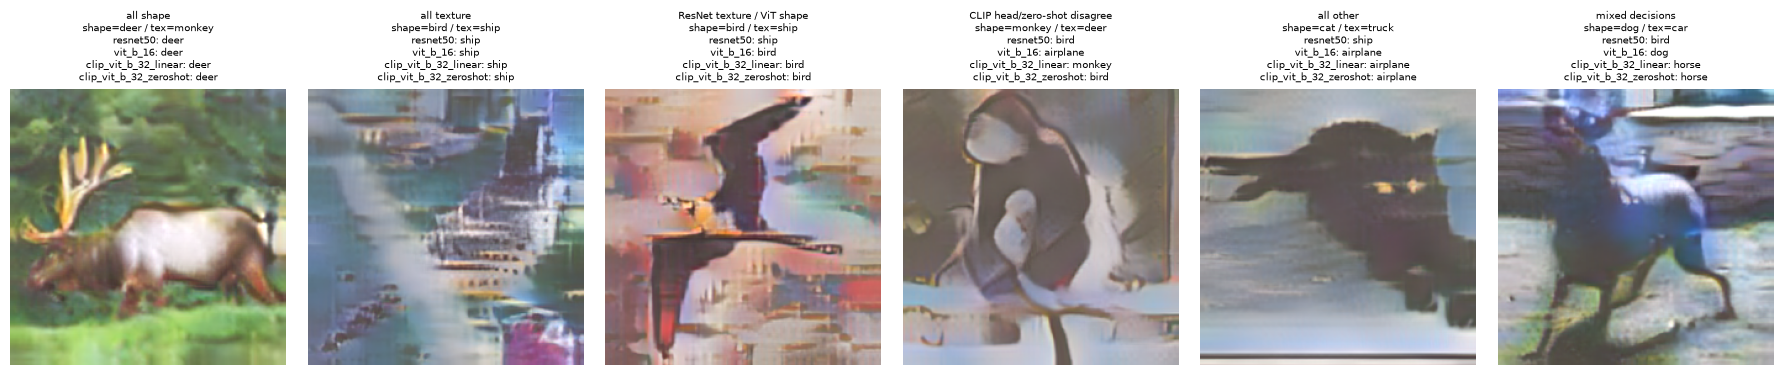

In [23]:
def show_cue_conflict_gallery(records, results_by_model, n=6):
    # Select predefined behavioral categories, never examples chosen for a
    # preferred aggregate conclusion. Selection occurs only after the blind
    # quantitative evaluation set has been frozen.
    pred_maps = {name: dict(zip(r["image_ids"], r["preds"])) for name, r in results_by_model.items()}
    categorized = []
    for i, rec in enumerate(records):
        iid = cuecal.cue_conflict_id(rec)
        decisions = {name: mx.classify_shape_texture(preds[iid], rec["content_class_idx"], rec["texture_class_idx"])
                     for name, preds in pred_maps.items()}
        values = list(decisions.values())
        if all(value == "shape" for value in values): category = "all shape"
        elif all(value == "texture" for value in values): category = "all texture"
        elif all(value == "other" for value in values): category = "all other"
        elif decisions["clip_vit_b_32_linear"] != decisions["clip_vit_b_32_zeroshot"]: category = "CLIP head/zero-shot disagree"
        elif decisions["resnet50"] == "texture" and decisions["vit_b_16"] == "shape": category = "ResNet texture / ViT shape"
        else: category = "mixed decisions"
        categorized.append((category, iid, i))
    priority = ["all shape", "all texture", "ResNet texture / ViT shape",
                "CLIP head/zero-shot disagree", "all other", "mixed decisions"]
    pick, used = [], set()
    for category in priority:
        matches = sorted((iid, i) for cat, iid, i in categorized if cat == category and i not in used)
        if matches and len(pick) < n:
            iid, i = matches[0]; pick.append((category, i)); used.add(i)
    for category, iid, i in sorted(categorized, key=lambda item: item[1]):
        if len(pick) >= n: break
        if i not in used: pick.append((category, i)); used.add(i)
    fig, axes = plt.subplots(1, len(pick), figsize=(3 * len(pick), 3.5))
    if len(pick) == 1:
        axes = [axes]
    for ax, (category, i) in zip(axes, pick):
        rec = records[i]
        img = rec["image"].permute(1, 2, 0).numpy()
        ax.imshow(np.clip(img, 0, 1))
        ax.axis("off")
        iid = cuecal.cue_conflict_id(rec)
        title_lines = [category, f"shape={rec['content_class']} / tex={rec['texture_class']}"]
        for name, r in results_by_model.items():
            pred_idx = dict(zip(r["image_ids"], r["preds"]))[iid]
            title_lines.append(f"{name}: {STL10_CLASSES[pred_idx]}")
        ax.set_title("\n".join(title_lines), fontsize=7)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "cue_conflict_gallery.png", dpi=150)
    plt.show()

show_cue_conflict_gallery(accepted_records, cue_results_by_model)


## 8b. Archived SSIM Calibration Diagnostic

The cells below preserve the earlier SSIM calibration as a diagnostic and
provenance record. It no longer selects the quantitative evaluation set. The
blind GUI review and balanced approved manifest in Section 8 are authoritative.

**Pre-registered pass/fail rubric.** **Fail** if the content shape is no longer
recognizable as its stated class, the style texture is effectively absent, or
the image is muddy/degenerate enough that neither cue is interpretable.
Otherwise **pass**. This wording was fixed before the archived ratings were collected.


In [24]:
calibration_config_path = RESULTS_DIR / "cue_conflict_calibration_config.json"
completed_sweep_path = RESULTS_DIR / "cue_conflict_threshold_sweep.csv"
if completed_sweep_path.exists() and calibration_config_path.exists():
    # Preserve the original 220-image calibration cohort after the final
    # generation buffer is raised to 30 candidates per bucket.
    calibration_config = load_json(calibration_config_path)
    ssim_summary = calibration_config["ssim_summary"]
    SWEEP_MIN = calibration_config["sweep_min"]
    SWEEP_MAX = calibration_config["sweep_max"]
    SWEEP_STEP = calibration_config["sweep_step"]
    SWEEP_THRESHOLDS = np.asarray(calibration_config["thresholds"], dtype=float)
    print("Using completed calibration config:", calibration_config)
else:
    ssim_summary = cuecal.plot_ssim_distribution(candidate_records)
    print("SSIM distribution summary:", ssim_summary)
    # Inspect the histogram before review. These explicit values are saved
    # before rating so threshold selection cannot move after seeing labels.
    SWEEP_MIN = 0.20
    SWEEP_MAX = 0.50
    SWEEP_STEP = 0.05
    SWEEP_THRESHOLDS = np.round(
        np.arange(SWEEP_MIN, SWEEP_MAX + SWEEP_STEP / 2, SWEEP_STEP), 10
    )
    save_json(
        {
            "ssim_summary": ssim_summary,
            "sweep_min": SWEEP_MIN,
            "sweep_max": SWEEP_MAX,
            "sweep_step": SWEEP_STEP,
            "thresholds": SWEEP_THRESHOLDS.tolist(),
            "range_decision": "Retained the preregistered 0.20--0.50 range: the distribution spans this interval and its lower tail is decision-relevant.",
            "tie_break": "kappa ties within 1e-9 select the stricter (higher) threshold",
            "positive_class": "fail",
        },
        calibration_config_path,
    )
print("Sweep thresholds:", SWEEP_THRESHOLDS)


Using completed calibration config: {'ssim_summary': {'count': 220, 'min': 0.21104690423125802, 'q05': 0.26873486116098405, 'median': 0.41742162634066027, 'q95': 0.5773951539590528, 'max': 0.7646439319509131}, 'sweep_min': 0.2, 'sweep_max': 0.5, 'sweep_step': 0.05, 'thresholds': [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5], 'range_decision': 'Retained the preregistered 0.20--0.50 range: the 220-image distribution spans this interval (min 0.211, q05 0.269, median 0.417) and its lower tail is decision-relevant.', 'tie_break': 'kappa ties within 1e-9 select the stricter (higher) threshold', 'positive_class': 'fail'}
Sweep thresholds: [0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


In [25]:
sweep_path = RESULTS_DIR / "cue_conflict_threshold_sweep.csv"
if sweep_path.exists():
    # A completed calibration must not be resampled after the Phase 3
    # candidate buffer changes from 22 to 30 images per bucket.
    completed_sweep = pd.read_csv(sweep_path)
    selected = completed_sweep.loc[completed_sweep["selected"].astype(str).str.lower() == "true"]
    print("Calibration already complete; selected row:")
    display(selected)
else:
    calibration_sample = cuecal.sample_for_review(
        candidate_records,
        sample_frac=0.10,
        seed_name="cue_conflict_threshold_audit",
    )
    print(
        f"Manual review sample: {len(calibration_sample)} unique images across "
        f"{len({record['bucket_key'] for record in calibration_sample})} buckets"
    )
    review_session = cuecal.ReviewSession(
        calibration_sample,
        thresholds=SWEEP_THRESHOLDS,
        ratings_path=RESULTS_DIR / "cue_conflict_manual_ratings.jsonl",
    )
    review_session.show()


Calibration already complete; selected row:


,threshold,agreement_pct,cohen_kappa,fail_precision,fail_recall,fail_f1,manual_pass,manual_fail,predicted_fail,selected,ranking_metric,tie_break_invoked,sweep_min,sweep_max,sweep_count
0,0.3,75.0,0.418605,1.0,0.375,0.545455,12,8,3,True,cohen_kappa,False,0.2,0.5,7


These archived threshold artifacts are diagnostic only. For the current run,
complete the blind review in `cue_review_app`, export the balanced 200-row
approved manifest, and rerun Section 8 before using any downstream
shape-bias, gallery, stability, or t-SNE output.


## 9. Step 4 — Translation

Reflection-pad then shifted-crop each of the 500 eval images by
δ ∈ {0, 8, 16, 32} px in each of 4 cardinal directions, keeping the output
224×224. For each δ, results are averaged across the 4 directions.


In [26]:
translation_rows = []
delta_values = [0, 8, 16, 32]

class TranslateDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset, delta, direction):
        self.base = base_subset
        self.delta = delta
        self.direction = direction
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        if self.delta == 0:
            out = img
        else:
            out = tr.translate_reflect(img.unsqueeze(0), self.delta, self.direction).squeeze(0)
        return out, lbl, iid

for delta in delta_values:
    directions = [tr.DIRECTIONS[0]] if delta == 0 else list(tr.DIRECTIONS)
    per_direction_metrics = {name: {"acc": [], "cons": []} for name in
                              ["resnet50", "vit_b_16", "clip_vit_b_32_linear", "clip_vit_b_32_zeroshot"]}
    for direction in directions:
        loader = dm.make_loader(TranslateDataset(eval_ds_clean, delta, direction), batch_size=100, shuffle=False)
        cond_name = f"translate_d{delta}_{direction}"
        results = evaluate_condition(cond_name, loader)
        for name, r in results.items():
            acc = mx.accuracy(r["preds"], r["labels"])
            clean_map = dict(zip(clean_results[name]["image_ids"], clean_results[name]["preds"]))
            aligned_clean_preds = [clean_map[i] for i in r["image_ids"]]
            cons = mx.prediction_consistency(aligned_clean_preds, r["preds"])
            per_direction_metrics[name]["acc"].append(acc)
            per_direction_metrics[name]["cons"].append(cons)
    for name, m in per_direction_metrics.items():
        translation_rows.append({
            "delta": delta, "model": name,
            "accuracy": float(np.mean(m["acc"])), "consistency_vs_clean": float(np.mean(m["cons"])),
        })

translation_df = pd.DataFrame(translation_rows)
translation_df.to_csv(RESULTS_DIR / "translation_results.csv", index=False)
translation_df


,delta,model,accuracy,consistency_vs_clean
0,0,resnet50,0.9900,1.0000
1,0,vit_b_16,0.9940,1.0000
2,0,clip_vit_b_32_linear,0.9840,1.0000
3,0,clip_vit_b_32_zeroshot,0.9760,1.0000
4,8,resnet50,0.9875,0.9975
5,8,vit_b_16,0.9910,0.9930
6,8,clip_vit_b_32_linear,0.9825,0.9875
7,8,clip_vit_b_32_zeroshot,0.9715,0.9745
8,16,resnet50,0.9875,0.9955
9,16,vit_b_16,0.9945,0.9975


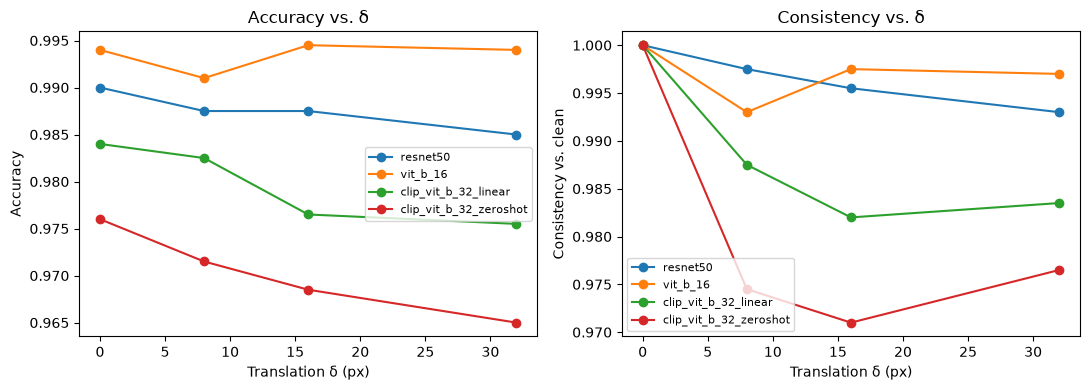

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in translation_df["model"].unique():
    sub = translation_df[translation_df["model"] == name].sort_values("delta")
    axes[0].plot(sub["delta"], sub["accuracy"], marker="o", label=name)
    axes[1].plot(sub["delta"], sub["consistency_vs_clean"], marker="o", label=name)
axes[0].set_xlabel("Translation δ (px)"); axes[0].set_ylabel("Accuracy"); axes[0].set_title("Accuracy vs. δ")
axes[1].set_xlabel("Translation δ (px)"); axes[1].set_ylabel("Consistency vs. clean"); axes[1].set_title("Consistency vs. δ")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "translation_curves.png", dpi=150)
plt.show()


## 10. Step 5 — Patch Structure

Each 224×224 eval image is divided into a 4×4 grid of 56×56 patches and
given a **fixed, per-image, seeded, non-identity permutation** (same
permutation reused across every backbone for that image).



In [28]:
patch_permutations = {iid: tr.make_patch_permutation(iid, grid=4).tolist() for iid in eval_image_ids}
save_json(patch_permutations, RESULTS_DIR / "patch_permutations.json")

class PatchShuffleDataset(torch.utils.data.Dataset):
    def __init__(self, base_subset):
        self.base = base_subset
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl, iid = self.base[i]
        perm = np.array(patch_permutations[iid])
        out = tr.patch_shuffle(img, perm, grid=4)
        return out, lbl, iid

shuffle_loader = dm.make_loader(PatchShuffleDataset(eval_ds_clean), batch_size=100, shuffle=False)
shuffle_results = evaluate_condition("patch_shuffle", shuffle_loader)
patch_shuffle_rows = summarize_vs_clean("patch_shuffle", shuffle_results, clean_results)
patch_shuffle_df = pd.DataFrame(patch_shuffle_rows)
patch_shuffle_df.to_csv(RESULTS_DIR / "patch_shuffle_results.csv", index=False)
patch_shuffle_df


,condition,model,accuracy,accuracy_delta_vs_clean,consistency_vs_clean
0,patch_shuffle,resnet50,0.922,-0.068,0.926
1,patch_shuffle,vit_b_16,0.942,-0.052,0.946
2,patch_shuffle,clip_vit_b_32_linear,0.858,-0.126,0.854
3,patch_shuffle,clip_vit_b_32_zeroshot,0.836,-0.140,0.828


## 11. Step 6 — Representation Analysis

For **grayscale**, **cue-conflict**, **translation (δ=32px, averaged across
the 4 directions)**, and **patch-shuffle**, we reuse the already-cached
frozen feature vectors (extracted while running Steps 2–5 above; no
recomputation needed here — `dm.extract_features` transparently returns the
cached tensors keyed per image by `(backbone, condition, image-id)` to compute a
representation-stability score `I_T` per backbone × intervention, and fit a
single 2D t-SNE projection per backbone on the combined clean+transformed
features.

In [29]:
REPR_CONDITIONS = ["grayscale", "cue_conflict", "translate_d32_up", "patch_shuffle"]
# NOTE: translation representation stability uses one representative
# direction (up) at delta=32, as permitted by the spec ("pick one
# representative delta ... or aggregate — decide and document"); we pick a
# single direction rather than an average across directions specifically
# for the *representation* analysis, since I_T and the projection need one
# concrete feature vector per image, whereas the earlier scalar accuracy/
# consistency metrics were already averaged across directions.

repr_backbones = {"resnet50": resnet, "vit_b_16": vit, "clip_vit_b_32": clip}

def get_cached_feats(backbone_name, condition, image_ids):
    cache_name = repr_backbones[backbone_name].cache_name
    cached = dm.load_cached_features(cache_name, condition, image_ids)
    assert cached is not None, f"Expected cached features for {backbone_name}/{condition}; run the corresponding step above first."
    id_to_row = {iid: i for i, iid in enumerate(cached["image_ids"])}
    order = [id_to_row[iid] for iid in image_ids]
    return cached["features"][order]

I_T_rows = []
for backbone_name in repr_backbones:
    clean_feats = get_cached_feats(backbone_name, "clean_eval", eval_image_ids)
    for cond in REPR_CONDITIONS:
        if cond == "cue_conflict":
            cond_ids = [cuecal.cue_conflict_id(rec) for rec in accepted_records]
            cond_feats = get_cached_feats(backbone_name, cond, cond_ids)
            # cue-conflict has no 1:1 correspondence with a single clean
            # image (each stylization mixes a content + a style image), so
            # I_T here is computed against the ORIGINAL CONTENT image's
            # clean feature instead of a matched eval-subset index.
            content_ids = [rec["content_id"] for rec in accepted_records]
            ref_feats = get_cached_feats(backbone_name, "clean_eval", content_ids)
        else:
            cond_feats = get_cached_feats(backbone_name, cond, eval_image_ids)
            ref_feats = clean_feats
        i_t = mx.representation_stability(ref_feats, cond_feats)
        I_T_rows.append({"backbone": backbone_name, "condition": cond, "I_T": i_t})

I_T_df = pd.DataFrame(I_T_rows)
I_T_df.to_csv(RESULTS_DIR / "representation_stability.csv", index=False)
I_T_df.pivot(index="backbone", columns="condition", values="I_T")


condition,cue_conflict,grayscale,patch_shuffle,translate_d32_up
backbone,,,,
clip_vit_b_32,0.695432,0.889984,0.749408,0.972450
resnet50,0.263586,0.804720,0.694613,0.935094
vit_b_16,0.255075,0.737712,0.634183,0.940526


**Projection method:** t-SNE (`sklearn.manifold.TSNE`, `perplexity=30`,
`metric="cosine"`, `init="pca"`, seed derived from `SEED=6304` via
`make_rng("tsne")`) was chosen over UMAP for its strong local-neighborhood
preservation on datasets of this scale (~1,000 points per plot: 500 clean +
500 transformed), which is what we care about here (do clean/transformed
pairs of the *same* image stay close?), and because it needs no extra
dependency beyond scikit-learn. One projection is fit **per backbone per
intervention**, on the **combined** clean+transformed feature matrix, so
both conditions live in the same 2D space — but different backbones/
interventions each get an independent fit, and their absolute coordinates
are **not** comparable to one another (only relative structure within a
single panel is meaningful).


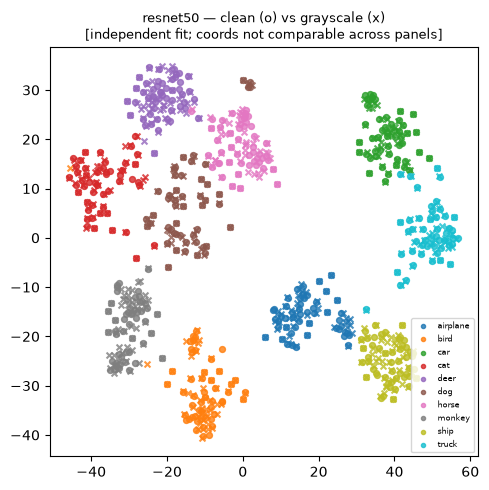

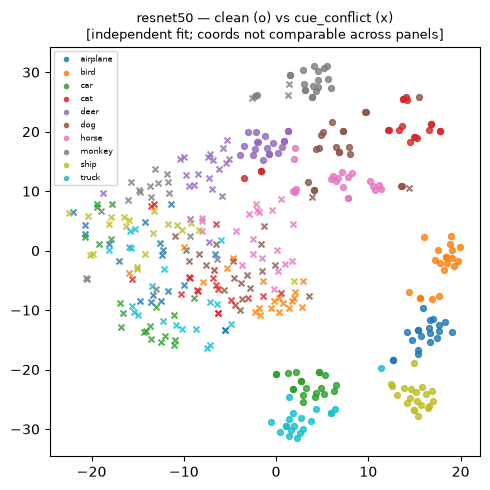

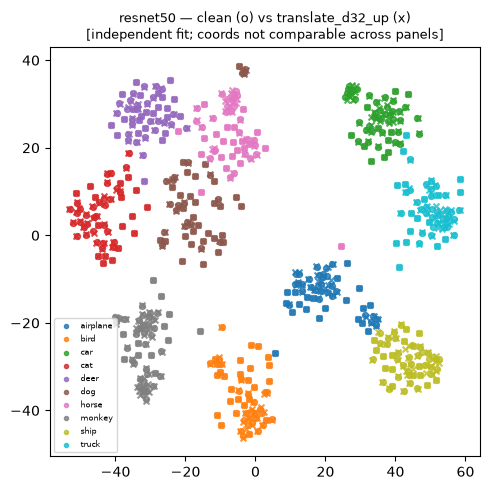

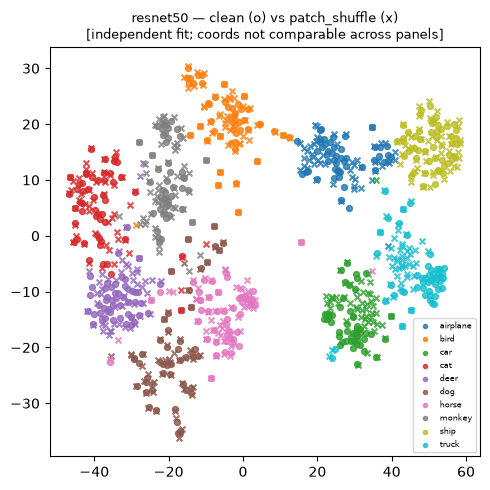

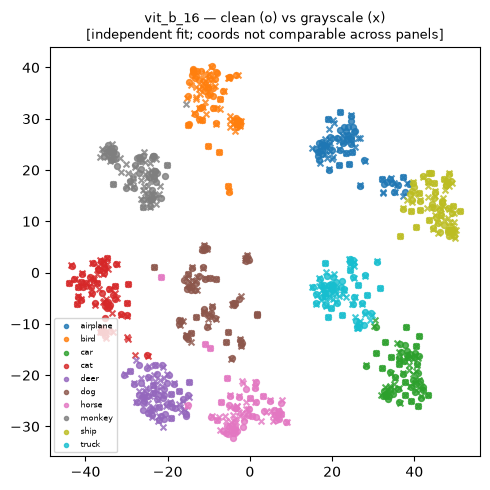

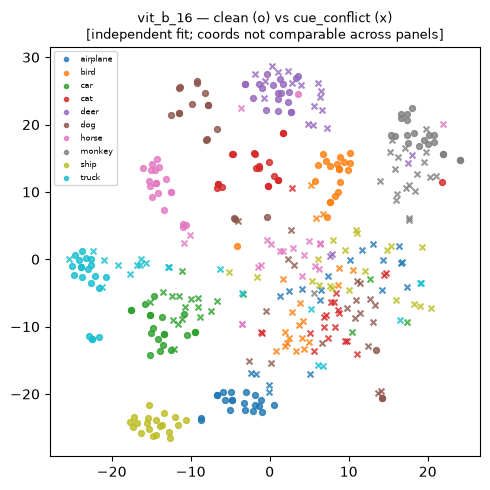

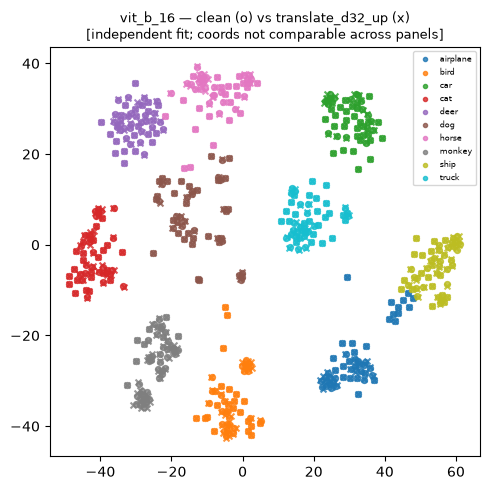

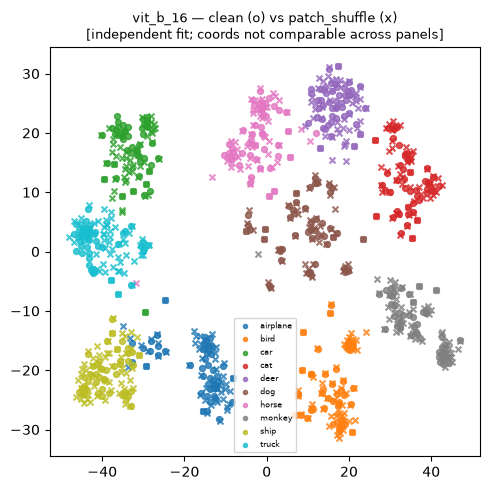

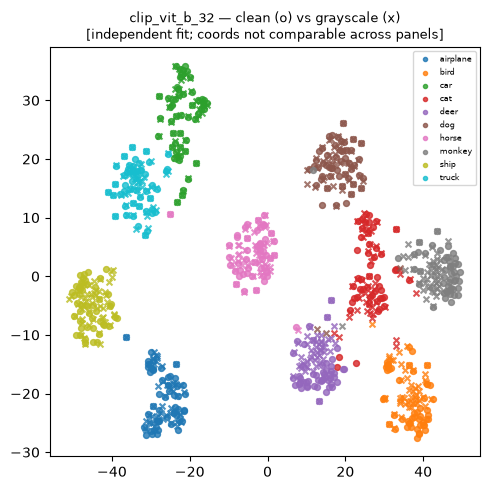

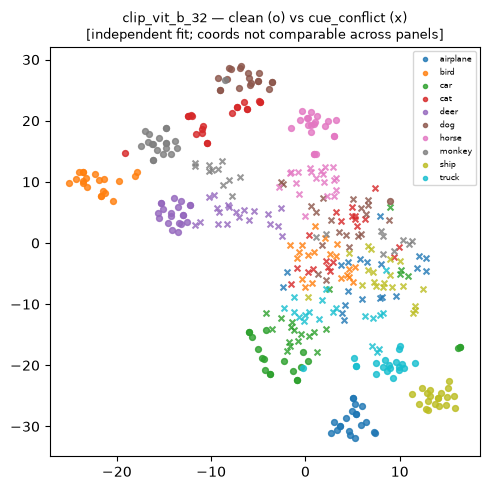

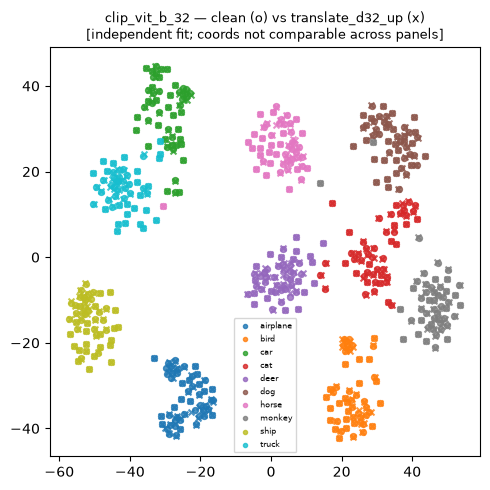

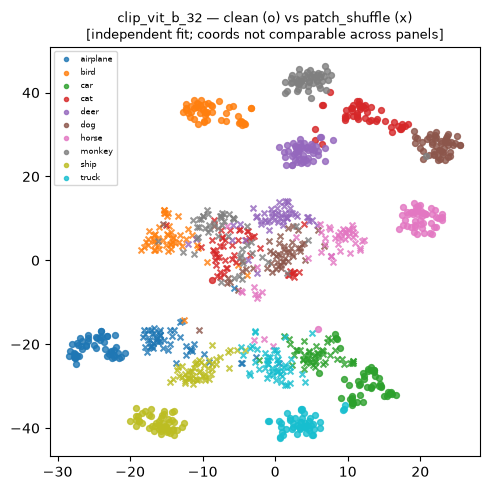

In [30]:
def plot_tsne_panel(backbone_name, condition, clean_feats, cond_feats, clean_labels):
    combined = torch.cat([clean_feats, cond_feats], dim=0).numpy()
    proj = mx.fit_2d_projection(combined, method="tsne", seed_name="tsne", perplexity=30)
    n = clean_feats.shape[0]
    proj_clean, proj_cond = proj[:n], proj[n:]

    fig, ax = plt.subplots(figsize=(5, 5))
    cmap = plt.get_cmap("tab10")
    for c in range(len(STL10_CLASSES)):
        mask = np.array(clean_labels) == c
        ax.scatter(proj_clean[mask, 0], proj_clean[mask, 1], color=cmap(c), marker="o", s=18,
                   label=STL10_CLASSES[c],
                   alpha=0.8)
        ax.scatter(proj_cond[mask, 0], proj_cond[mask, 1], color=cmap(c), marker="x", s=18, alpha=0.8)
    ax.legend(fontsize=6, markerscale=0.7)
    ax.set_title(f"{backbone_name} — clean (o) vs {condition} (x)\n[independent fit; coords not comparable across panels]", fontsize=9)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"tsne_{backbone_name}_{condition}.png", dpi=150)
    plt.show()

for backbone_name in repr_backbones:
    clean_feats = get_cached_feats(backbone_name, "clean_eval", eval_image_ids)
    for cond in REPR_CONDITIONS:
        if cond == "cue_conflict":
            cond_ids = [cuecal.cue_conflict_id(rec) for rec in accepted_records]
            cond_feats = get_cached_feats(backbone_name, cond, cond_ids)
            content_ids = [rec["content_id"] for rec in accepted_records]
            ref_feats = get_cached_feats(backbone_name, "clean_eval", content_ids)
            ref_labels = [rec["content_class_idx"] for rec in accepted_records]
            plot_tsne_panel(backbone_name, cond, ref_feats, cond_feats, ref_labels)
            continue
        cond_feats = get_cached_feats(backbone_name, cond, eval_image_ids)
        plot_tsne_panel(backbone_name, cond, clean_feats, cond_feats, eval_labels)


## 12. Summary Consolidation

A quick cross-condition view of accuracy drop and consistency for every
model, to support the write-up's overall comparison across the four
intervention families.


In [31]:
summary_rows = []
summary_rows += [{"condition": "clean", "model": r["model"], "accuracy": r["accuracy"], "consistency_vs_clean": 1.0}
                  for r in clean_baseline_df.to_dict("records")]
summary_rows += color_bias_df[["condition", "model", "accuracy", "consistency_vs_clean"]].to_dict("records")
summary_rows += patch_shuffle_df[["condition", "model", "accuracy", "consistency_vs_clean"]].to_dict("records")
summary_rows += [{"condition": f"translate_d{d}", "model": m, "accuracy": a, "consistency_vs_clean": c}
                  for d, m, a, c in translation_df[["delta", "model", "accuracy", "consistency_vs_clean"]].values]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / "all_conditions_summary.csv", index=False)
summary_df.pivot_table(index="model", columns="condition", values="accuracy")


condition,clean,color_swap,grayscale,patch_shuffle,translate_d0,translate_d16,translate_d32,translate_d8
model,,,,,,,,
clip_vit_b_32_linear,0.984,0.974,0.968,0.858,0.984,0.9765,0.9755,0.9825
clip_vit_b_32_zeroshot,0.976,0.964,0.964,0.836,0.976,0.9685,0.9650,0.9715
resnet50,0.990,0.990,0.968,0.922,0.990,0.9875,0.9850,0.9875
vit_b_16,0.994,0.996,0.976,0.942,0.994,0.9945,0.9940,0.9910
